# Exploratory Data Analysis

Run this after downloading your chosen dataset(s) into `data/raw/`. Fill in each section as you go — this notebook is also a deliverable artifact (dataset statistics belong in your final report, Section 3/4).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display

from audio_features import load_audio, extract_log_mel, extract_chroma, segment_track
from graph_builder import estimate_chord_sequence, build_chord_transition_graph, build_segment_similarity_graph

## 1. Dataset overview
Load your metadata CSV / JSON (genre labels, tags, captions) and report:
- number of tracks
- label distribution (class imbalance!)
- average track duration
- train/val/test split sizes

tracks: 999
split
train    799
val      100
test     100
Name: count, dtype: int64


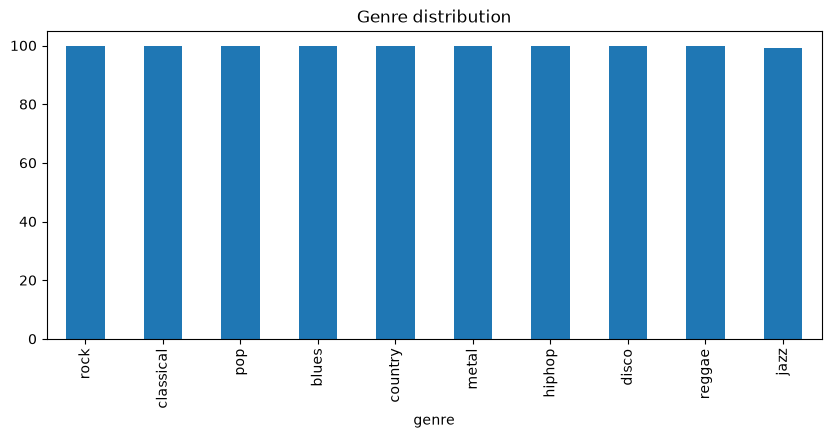

          track_id                                               text  \
0       rock.00056  A fast, energetic recording at about 136 BPM i...   
1  classical.00061  A fast, energetic recording at about 152 BPM i...   
2        pop.00073  A fast, energetic recording at about 129 BPM i...   
3      blues.00046  A moderately paced recording at about 123 BPM ...   
4    country.00067  A fast, energetic recording at about 129 BPM i...   

                             tags      genre valence arousal  split  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]       rock    None    None  train  
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]  classical    None    None  train  
2  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]        pop    None    None  train  
3  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]      blues    None    None  train  
4  [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]    country    None    None  train  


In [2]:
import json
from pathlib import Path

splits_dir = Path('../data/splits')
rows = []
for split in ['train', 'val', 'test']:
    path = splits_dir / f'{split}.json'
    if path.exists() and path.stat().st_size > 0:
        with open(path) as f:
            data = json.load(f)
        for r in data:
            r = dict(r)
            r['split'] = split
            rows.append(r)

metadata = pd.DataFrame(rows)
print('tracks:', len(metadata))
print(metadata['split'].value_counts())
if len(metadata):
    vocab_path = splits_dir / 'label_vocab.json'
    vocab = json.load(open(vocab_path)) if vocab_path.exists() else None
    if vocab is not None:
        genres = [vocab[np.argmax(t)] for t in metadata['tags']]
        metadata['genre'] = genres
        metadata['genre'].value_counts().plot(kind='bar', figsize=(10,4), title='Genre distribution')
        plt.show()
    print(metadata.head())

## 2. Audio feature inspection
Sanity-check the mel-spectrogram / chroma extraction on a handful of tracks across different genres.

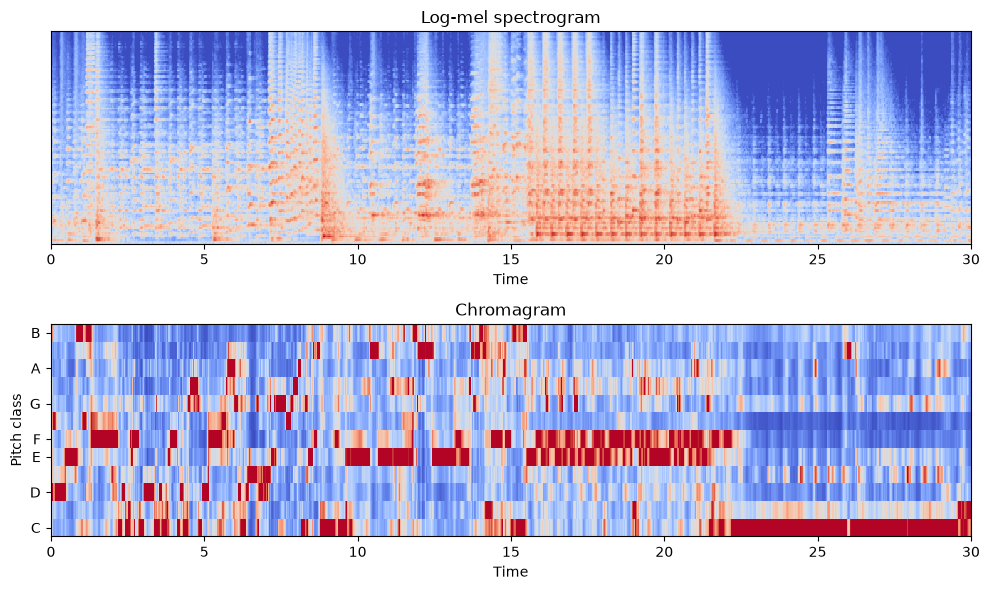

duration_sec: 30.013333333333332


In [3]:
example_path = '../data/raw/jazz/jazz.00000.wav'
y = load_audio(example_path)
mel = extract_log_mel(y)
chroma = extract_chroma(y)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
librosa.display.specshow(mel, ax=axes[0], x_axis='time')
axes[0].set_title('Log-mel spectrogram')
librosa.display.specshow(chroma, ax=axes[1], x_axis='time', y_axis='chroma')
axes[1].set_title('Chromagram')
plt.tight_layout()
plt.show()
print('duration_sec:', len(y) / 22050)

## 3. Graph statistics
For a sample of tracks, report: average number of nodes, average number of edges, degree distribution. This directly informs the 'graph construction documented' rubric line (Dataset & preprocessing, 15%).

graphs inspected: 300
nodes    mean 19.0  min 19  max 19
edges    mean 42.9  min 36  max 80
density  mean 0.125  fraction complete 0.000
degree   mean 2.26  max 8


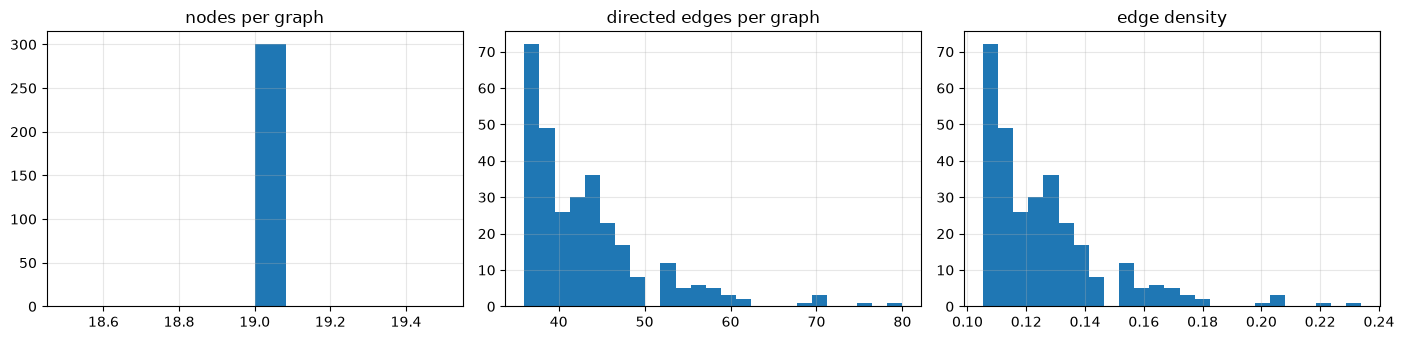


degree distribution percentiles: [2. 2. 3.]


In [4]:
from pathlib import Path

from graph_builder import load_graph

graph_paths = sorted(Path('../data/processed/graphs').glob('*.pt'))[:300]
node_counts, edge_counts, densities, degrees = [], [], [], []
for path in graph_paths:
    g = load_graph(str(path))
    n, e = int(g.x.shape[0]), int(g.edge_index.shape[1])
    node_counts.append(n)
    edge_counts.append(e)
    densities.append(e / max(n * (n - 1), 1))
    degrees.extend(np.bincount(g.edge_index[0].numpy(), minlength=n).tolist())

print(f'graphs inspected: {len(graph_paths)}')
print(f'nodes    mean {np.mean(node_counts):.1f}  min {np.min(node_counts)}  max {np.max(node_counts)}')
print(f'edges    mean {np.mean(edge_counts):.1f}  min {np.min(edge_counts)}  max {np.max(edge_counts)}')
print(f'density  mean {np.mean(densities):.3f}  fraction complete {np.mean(np.array(densities) >= 0.999):.3f}')
print(f'degree   mean {np.mean(degrees):.2f}  max {np.max(degrees)}')

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(node_counts, bins=12); axes[0].set_title('nodes per graph')
axes[1].hist(edge_counts, bins=25); axes[1].set_title('directed edges per graph')
axes[2].hist(densities, bins=25); axes[2].set_title('edge density')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Why density matters: an earlier configuration used non-overlapping 5 s windows
# with tau = 0.85 on un-standardized features. That produced 6-node graphs with
# density 0.93 (76% of them complete), and on a complete graph GraphSAGE message
# passing collapses to mean pooling -- the GNN had no structure to exploit.
print('\ndegree distribution percentiles:',
      np.percentile(degrees, [10, 50, 90]).round(2))

## 4. Text statistics and the label-leakage check

The BERT branch reads captions written from **audio descriptors only** (`src/preprocess.py::generate_caption`).
The check below is the important one: if the caption were a function of the genre label, every
track of a genre would share one string and BERT could read the answer off its own input.
We therefore report the number of unique captions and the size of the largest group of
tracks sharing an identical caption.

tracks:                 999
unique captions:        971
largest identical group: 2
mean caption length:     54.1 words

OK: captions are essentially unique per track, so the text branch cannot act as a label lookup table.


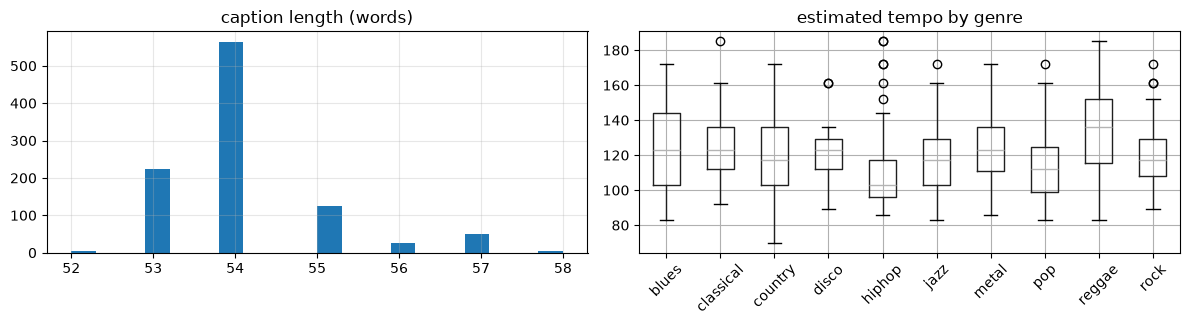


Example captions:
 - A fast, energetic recording at about 136 BPM in E major, with a very bright, treble-heavy timbre and a dense stream of note onsets. Its harmony centres on E major, E minor and D major, the texture is dominated by percussive attacks, and loudness varies moderately across the clip, with noticeable noise and distortion in the spectrum.
 - A fast, energetic recording at about 152 BPM in C major, with a warm, rounded timbre and a dense stream of note onsets. Its harmony centres on C major, A minor and F major, the texture balances sustained harmony with percussive attacks, and loudness swings strongly across the clip, with a clean, tonal spectrum.
 - A fast, energetic recording at about 129 BPM in D major, with a very bright, treble-heavy timbre and a dense stream of note onsets. Its harmony centres on D major, F# minor and G major, the texture is dominated by percussive attacks, and loudness varies moderately across the clip, with noticeable noise and distortion in th

In [5]:
from collections import Counter

captions = metadata['text'].tolist()
counts = Counter(captions)

print(f'tracks:                 {len(captions)}')
print(f'unique captions:        {len(counts)}')
print(f'largest identical group: {max(counts.values())}')
print(f'mean caption length:     {np.mean([len(c.split()) for c in captions]):.1f} words')

# A caption -> genre lookup would show up as len(counts) == number of genres.
if len(counts) > 0.9 * len(captions):
    print('\nOK: captions are essentially unique per track, so the text branch '
          'cannot act as a label lookup table.')
else:
    print('\nWARNING: captions repeat heavily - check for label leakage.')

lengths = [len(c.split()) for c in captions]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(lengths, bins=20); axes[0].set_title('caption length (words)')
axes[0].grid(alpha=0.3)

# Descriptor spread by genre: this is the signal the text branch actually has.
# The estimated tempo is embedded in each caption ("... at about NN BPM ...").
import re
metadata['tempo_bpm'] = [float(m.group(1)) if (m := re.search(r'about (\d+) BPM', c)) else np.nan
                         for c in metadata['text']]
metadata.boxplot(column='tempo_bpm', by='genre', ax=axes[1], rot=45)
axes[1].set_title('estimated tempo by genre'); axes[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout(); plt.show()

print('\nExample captions:')
for text in captions[:3]:
    print(' -', text)